In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline

np.random.seed(2)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools

from tensorflow.keras.utils import to_categorical
 # convert to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from keras.callbacks import ReduceLROnPlateau


sns.set(style='white', context='notebook', palette='deep')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


![image.png](attachment:image.png)

# 1. Data preparation
##  Load data

In [3]:
# load the dataset
train=pd .read_csv("/content/drive/MyDrive/CNN/train/train.csv")
test= pd.read_csv("/content/drive/MyDrive/CNN/test_ApKoW4T.csv")


In [4]:
train.head()

,image,category
0,2823080.jpg,1
1,2870024.jpg,1
2,2662125.jpg,2
3,2900420.jpg,3
4,2804883.jpg,2


In [5]:
test.head()

,image
0,1007700.jpg
1,1011369.jpg
2,1051155.jpg
3,1062001.jpg
4,1069397.jpg


In [6]:
# split target and features
Y_train = train['category']
X_train = train.drop('category', axis=1)

In [7]:
# count the number of samples for each category
Y_train.value_counts()

,count
category,
1,2120
5,1217
2,1167
3,916
4,832


In [8]:
# check for null and missing values
X_train.isnull().sum()
test.isnull().sum()
print ("Number of missing values in train dataset: ", X_train.isnull().sum().sum())
print ("Number of missing values in test dataset: ", test.isnull().sum().sum())

Number of missing values in train dataset:  0
Number of missing values in test dataset:  0


In [9]:
# dictionary ship encoding
ship = {'Cargo': 1,
        'Military': 2,
        'Carrier': 3,
        'Cruise': 4,
        'Tankers': 5}
# reverse the ship type dictionary
ship = dict([[v,k] for k,v in ship.items()])

In [10]:
train['ship'] = train['category'].map(ship).astype('category')
train['ship'].value_counts(normalize=False)

,count
ship,
Cargo,2120
Tankers,1217
Military,1167
Carrier,916
Cruise,832


In [11]:
!unrar x -o+ "/content/drive/MyDrive/CNN/train/images.rar" "/content/images/"

Streaming output truncated to the last 5000 lines.
Extracting  /content/images/images/2829342.jpg                            44%  OK 
Extracting  /content/images/images/2829344.jpg                            44%  OK 
Extracting  /content/images/images/2829347.jpg                            44%  OK 
Extracting  /content/images/images/2829351.jpg                            44%  OK 
Extracting  /content/images/images/2829357.jpg                            44%  OK 
Extracting  /content/images/images/2829359.jpg                            44%  OK 
Extracting  /content/images/images/2829362.jpg                            44%  OK 
Extracting  /content/images/images/2829366.jpg                            44%  OK 
Extracting  /content/images/images/2829369.jpg                            44%  OK 
Extracting  /content/images/images/2829372.jpg                            44%  OK 
Extracting  /content/images/i

# Normalization

# Data Generators (Augmentation on train only)

In [12]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Keras needs string labels for flow_from_dataframe
train['category'] = train['category'].astype(str)

# مسار الصور الجديد في Colab بعد فك الضغط
IMAGES_DIR = '/content/images'
if os.path.exists('/content/images/images'):
    IMAGES_DIR = '/content/images/images'

IMG_SIZE = (224, 224)
BATCH = 32

# Training generator: WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest',
    validation_split=0.2,
)

# Validation generator: rescale ONLY (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=IMAGES_DIR,
    x_col='image',
    y_col='category',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=train,
    directory=IMAGES_DIR,
    x_col='image',
    y_col='category',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

Found 5002 validated image filenames belonging to 5 classes.
Found 1250 validated image filenames belonging to 5 classes.


# Class Weights (the data is imbalanced)

In [13]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_generator.classes)
weights = compute_class_weight('balanced', classes=classes, y=train_generator.classes)
class_weights = dict(zip(classes, weights))
print(train_generator.class_indices)
print(class_weights)

{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4}
{np.int64(0): np.float64(0.5905548996458088), np.int64(1): np.float64(1.061995753715499), np.int64(2): np.float64(1.377961432506887), np.int64(3): np.float64(1.490909090909091), np.int64(4): np.float64(1.032404540763674)}


# Model Architecture (Transfer Learning - MobileNetV2)

In [14]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base.trainable = False   # Phase 1: freeze the pretrained base

inputs = layers.Input(shape=(224, 224, 3))
x = layers.Rescaling(2.0, offset=-1.0)(inputs)      # generator gives [0,1] -> MobileNetV2 expects [-1,1]
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)              # instead of Flatten
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(5, activation='softmax')(x)
model = models.Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Model Compilation

In [15]:
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,717 (9.26 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

# Callbacks

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint = ModelCheckpoint('best_ship_model.keras', monitor='val_loss',
                             save_best_only=True, mode='min', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2,
                              min_lr=1e-6, verbose=1)

callbacks_list = [checkpoint, early_stopping, reduce_lr]

# Model Training - Phase 1 (train the new head only)

In [17]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.5945 - loss: 1.1186
Epoch 1: val_loss improved from None to 0.45906, saving model to best_ship_model.keras

Epoch 1: finished saving model to best_ship_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 127s 684ms/step - accuracy: 0.6903 - loss: 0.8530 - val_accuracy: 0.8232 - val_loss: 0.4591 - learning_rate: 0.0010
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.7846 - loss: 0.5384
Epoch 2: val_loss improved from 0.45906 to 0.39375, saving model to best_ship_model.keras

Epoch 2: finished saving model to best_ship_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 473ms/step - accuracy: 0.7915 - loss: 0.5288 - val_accuracy: 0.8504 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8066 - loss: 0.4845
Epoch 3: val_loss did not improve from 0.39375
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 472ms/step - accuracy: 0.8117 - loss: 0.4833 - val_accuracy: 0.8496 - val_lo

# Model Training - Phase 2 (Fine-tuning the last 30 layers)

In [18]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

# very small learning rate for fine-tuning
model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_ft = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7722 - loss: 0.6036
Epoch 1: val_loss did not improve from 0.34982
157/157 ━━━━━━━━━━━━━━━━━━━━ 110s 589ms/step - accuracy: 0.7825 - loss: 0.5616 - val_accuracy: 0.8008 - val_loss: 0.5628 - learning_rate: 1.0000e-05
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8184 - loss: 0.4827
Epoch 2: val_loss did not improve from 0.34982

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
157/157 ━━━━━━━━━━━━━━━━━━━━ 78s 495ms/step - accuracy: 0.8149 - loss: 0.4688 - val_accuracy: 0.7784 - val_loss: 0.6498 - learning_rate: 1.0000e-05
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8314 - loss: 0.4241
Epoch 3: val_loss did not improve from 0.34982
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 487ms/step - accuracy: 0.8305 - loss: 0.4316 - val_accuracy: 0.7904 - val_loss: 0.5745 - learning_rate: 2.0000e-06
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.8432

# Training Curves

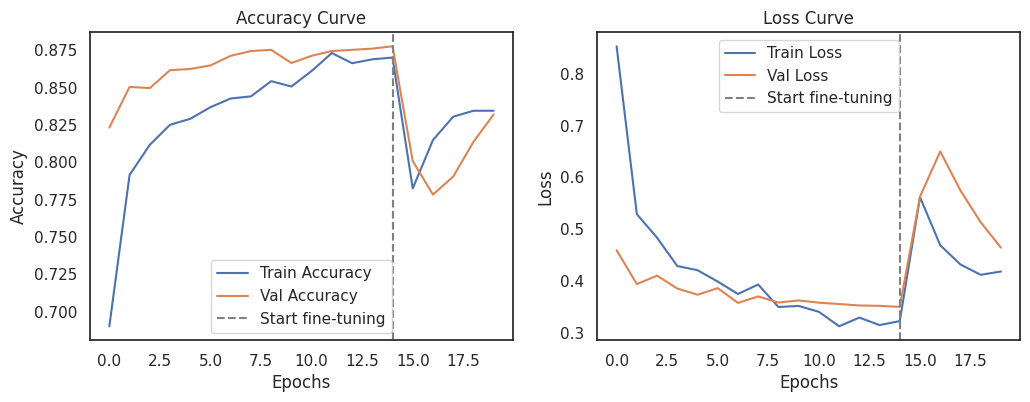

In [19]:
import matplotlib.pyplot as plt

# merge phase 1 + phase 2 histories
acc     = history.history['accuracy']     + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss    = history.history['loss']         + history_ft.history['loss']
val_loss= history.history['val_loss']     + history_ft.history['val_loss']
split   = len(history.history['accuracy'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(split - 1, color='gray', linestyle='--', label='Start fine-tuning')
plt.title('Accuracy Curve'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(split - 1, color='gray', linestyle='--', label='Start fine-tuning')
plt.title('Loss Curve'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.show()

# Evaluation (Classification Report + Confusion Matrix)

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step
              precision    recall  f1-score   support

       Cargo       0.93      0.61      0.74       426
    Military       0.99      0.83      0.91       225
     Carrier       0.99      0.90      0.94       190
      Cruise       0.95      0.93      0.94       161
     Tankers       0.52      0.94      0.67       248

    accuracy                           0.80      1250
   macro avg       0.88      0.84      0.84      1250
weighted avg       0.87      0.80      0.81      1250



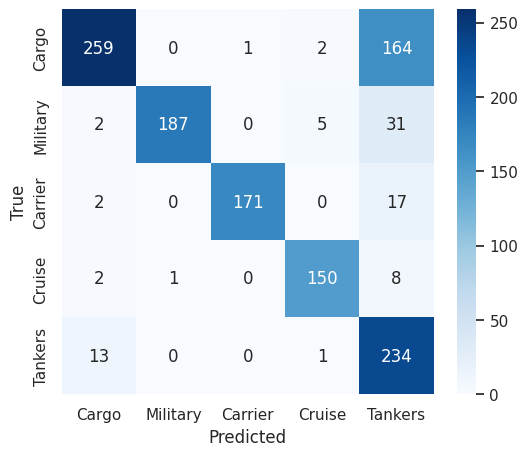

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_generator.reset()
pred = model.predict(val_generator)
y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

idx_to_name = {v: ship[int(k)] for k, v in val_generator.class_indices.items()}
names = [idx_to_name[i] for i in range(5)]

print(classification_report(y_true, y_pred, target_names=names))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
            xticklabels=names, yticklabels=names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

# Predict on the Test set

In [21]:
# NOTE: change TEST_DIR if the test images are in a different folder
TEST_DIR = IMAGES_DIR

test_datagen = ImageDataGenerator(rescale=1./255)   # rescale only, no augmentation
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test, directory=TEST_DIR, x_col='image', y_col=None,
    target_size=IMG_SIZE, batch_size=BATCH, class_mode=None, shuffle=False,
)

test_pred = model.predict(test_generator)
pred_idx = np.argmax(test_pred, axis=1)

# map generator index back to the original category number (1..5)
inv = {v: int(k) for k, v in train_generator.class_indices.items()}
submission = pd.DataFrame({
    'image': test['image'],
    'category': [inv[i] for i in pred_idx],
})
submission.to_csv('submission.csv', index=False)
submission.head()

Found 2680 validated image filenames.
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step


,image,category
0,1007700.jpg,4
1,1011369.jpg,4
2,1051155.jpg,4
3,1062001.jpg,2
4,1069397.jpg,4
